In [1]:
import os
import joblib
import pickle
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams, cycler
from matplotlib.cm import ScalarMappable
import seaborn as sns
import tensorflow as tf
from scipy.stats import pearsonr, gaussian_kde, ecdf
from sklearn.decomposition import PCA
import sys
sys.path.append(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1]))
from sgcc11 import *

In [2]:
plt.rcParams['figure.dpi'] = 300
fontsize = 8
linewidth = 0.5

In [3]:
plot_bounds = {
    "fts": [0, 175],
    "t": [40, 125],
    "ampc": [0.01, 0.2],
    'ampm': [0,3],
    "ampg": [0.1, 4],
    "ampw": [0.01,0.08],
    "d": [10, 40],
    "inh_d": [0, 40],
    "inh_w": [0, 3],
}

In [4]:
X = tf.convert_to_tensor([0.02,0.04,0.08,0.1,0.12,0.16,0.2,0.24,0.28,0.32], dtype = tf.float32)

In [5]:
v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'v1_ori_phase_condition_pcascores_wcomp.pkl')
v1_scores = pd.read_pickle(v1_xs_file)
v1_scores_condition_averaged = np.array([np.array(x) for x in v1_scores.scores.values]).mean(0)
Y_true = v1_scores_condition_averaged[:2,:,:].transpose(0,2,1)

In [6]:
P = joblib.load(
    os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'best_permutation.pkl')
)

In [7]:
modfile = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'sgcc_mop_4_18_26.pkl')
with open(modfile, 'rb') as f:
    optimized_model = pickle.load(f)

In [8]:
loss_decay = optimized_model['loss_decay']
last_epoch = loss_decay[-1]

In [9]:
upper_bounds = [0.08, 0.16, 0.24]

optimizations = []
for v1 in range(2):
    for dlgn in range(3):
        for u in upper_bounds:
            param_bounds = {
                "fts": [0, 175],
                "t": [40, 125],
                "ampc": [0.01, 0.1],
                'ampm': [0,3],
                "ampg": [0.1, 4],
                "ampw": [0.01, u],
                "d": [10, 40],
                "inh_d": [0, 40],
                "inh_w": [0, 3],
            }

            dLGN_params = optimized_model['scaled_param_history']['dLGN_params'][np.argsort(last_epoch)[:1000],-1]

            model = SGCCircuit(param_bounds, enforce_permutation=P[:1000])
            model.initialize_random_parameters(n_v1=2,n_lgn=3,n_sample=1000)
            model.update_transform()

            dLGN_params[:,v1,dlgn,5,:,:] = model.dlgn_raw[:,v1,dlgn,5,:,:].numpy()

            params = {
                'dLGN_params': dLGN_params,
                'V1_params': optimized_model['scaled_param_history']['V1_params'][np.argsort(last_epoch)[:1000],-1]
            }

            # apply a jitter
            p = {x[0]:x[1] + tf.random.uniform(x[1].shape, -0.5, 0.5) 
                for x in params.items()}
            
            model = SGCCircuit(param_bounds)
            model.load_saved_parameters(p)

            # initialize the optimizer
            optimizer = Optimize(model, epochs=1000, loss_threshold=0)

            # fit the model
            loss_decay = optimizer.fit(X, Y_true)
            #optimizer.save_state(f'conditional_optimization_ampc_upper_{u}')
            optimizations.append([
                optimizer.outputs['param_history']['dLGN_params'][:,-1][:,v1,dlgn,5,0,0], # x
                optimizer.outputs['loss_decay'][-1], # y
            ])
            del model
            del optimizer

Optimizer initialized with <keras.optimizers.optimizer_v2.adam.Adam object at 0x0000018853D21EE0>
Training step = 0, N_exploration_samples = 1000,
min_loss = 0.16958442330360413
med_loss = 0.6878656148910522
max_loss = 2.3759100437164307

Training step = 100, N_exploration_samples = 1000,
min_loss = 0.12568622827529907
med_loss = 0.40653109550476074
max_loss = 1.6168941259384155

Training step = 200, N_exploration_samples = 1000,
min_loss = 0.10332369059324265
med_loss = 0.27125084400177
max_loss = 1.135238528251648

Training step = 300, N_exploration_samples = 1000,
min_loss = 0.09344304352998734
med_loss = 0.20451180636882782
max_loss = 0.8211573362350464

Training step = 400, N_exploration_samples = 1000,
min_loss = 0.08750289678573608
med_loss = 0.16935783624649048
max_loss = 0.6206063032150269

Training step = 500, N_exploration_samples = 1000,
min_loss = 0.08377565443515778
med_loss = 0.14878147840499878
max_loss = 0.49544745683670044

Training step = 600, N_exploration_samples =

In [10]:
optimizations = np.array(optimizations).reshape(2,3,3,2,1000)

In [30]:
from sklearn.linear_model import LinearRegression

In [32]:
optimizations.shape

(2, 3, 3, 2, 1000)

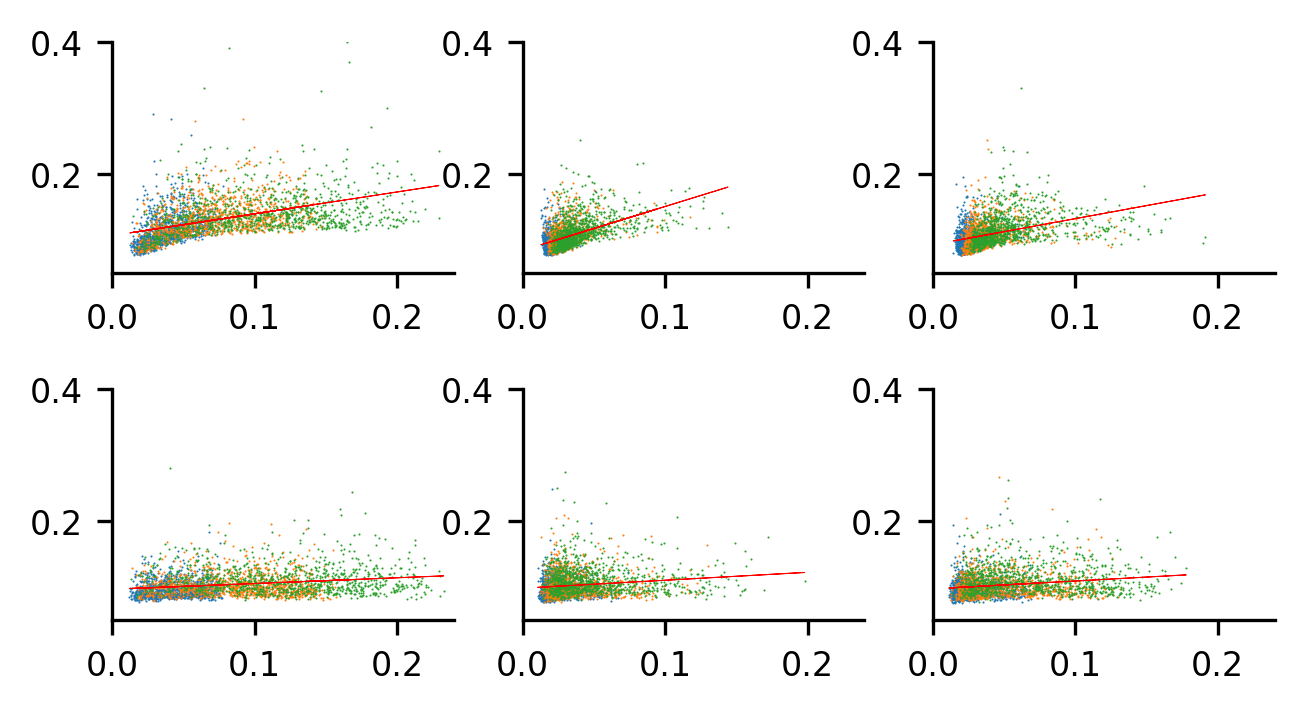

In [ ]:
fig, ax = plt.subplots(2,3, figsize = (5,2.5))
for row in range(2):
    for col in range(3):
        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)
        #ax[row, col].set_ylim(0.05,0.4)
        ax[row, col].set_xlim(0,0.24)
        x = optimizations[row,col,:,0,:].flatten().reshape(-1,1)
        y = optimizations[row,col,:,1,:].flatten().reshape(-1,1)
        reg = LinearRegression()
        reg.fit(x,y)
        y_line = reg.predict(x)
        ax[row,col].plot(x, y_line, linewidth = 0.25, color = 'red')
        for i in range(3):
            x = optimizations[row,col,i,0,:].flatten()
            y = optimizations[row,col,i,1,:].flatten()
            ax[row, col].scatter(x,y, s = 0.25, linewidth = 0)
fig.subplots_adjust(hspace=0.5)

Text(0, 0.5, 'Loss (MSE)')

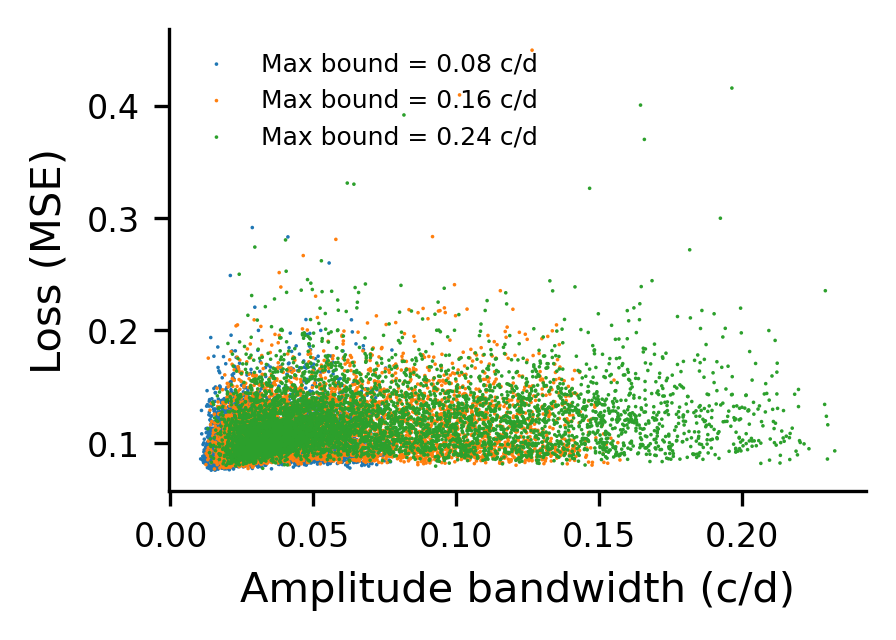

In [12]:
fig, ax = plt.subplots(figsize = (3,2))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize = fontsize)
thresh = 0.08
under_thresh = []
for i in range(3):
    x = optimizations[:,:,i,0,:].flatten()
    y = optimizations[:,:,i,1,:].flatten()
    under_thresh.append(len(np.where(y<thresh)[0]))
    ax.scatter(x,y, label = f"Max bound = {upper_bounds[i]} c/d", s = 0.75, edgecolors='none')
ax.legend(fontsize = 6, frameon = False)
ax.set_xlabel("Amplitude bandwidth (c/d)")
#ax.set_ylim(0.05,0.2)
ax.set_ylabel("Loss (MSE)")

AttributeError: 'numpy.ndarray' object has no attribute 'outputs'

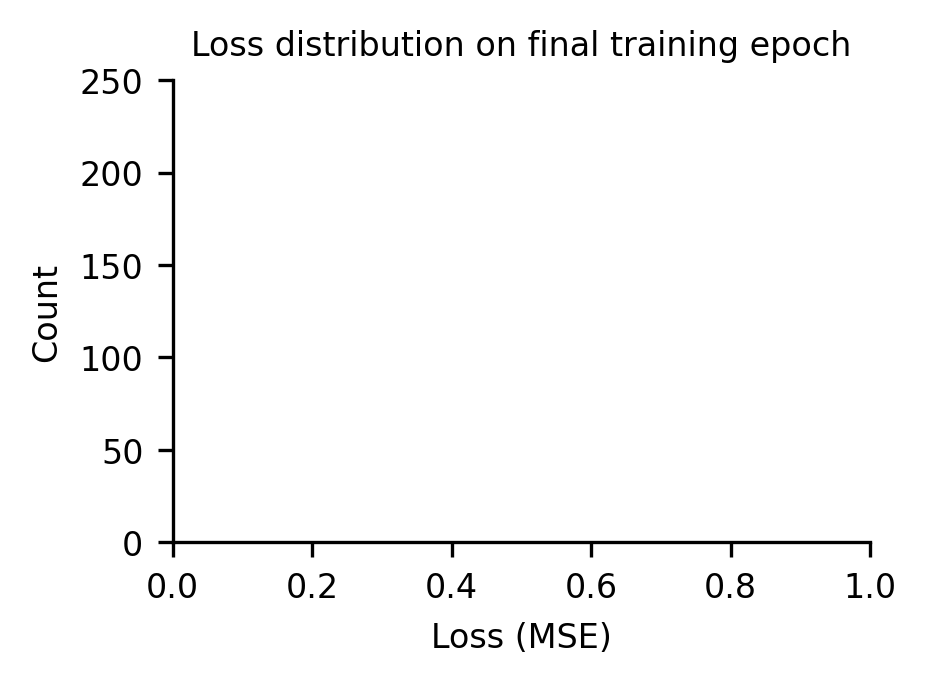

In [13]:
fig, ax = plt.subplots(figsize = (3,2))

ax.tick_params(labelsize = fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel("Count", fontsize = fontsize)
ax.set_xlabel("Loss (MSE)", fontsize = fontsize)
ax.set_ylim(0,250)
ax.set_title("Loss distribution on final training epoch", fontsize = fontsize)
for i in range(3):
    y = optimizations[i].outputs['loss_decay'][-1]
    ax.hist(y, bins = 100, label = f"Max bound = {upper_bounds[i]} c/d", histtype='step', linewidth = 0.5)

ax.legend(fontsize = 6, frameon = False)

Text(0, 0.5, 'Number of solutions with MSE < 0.08')

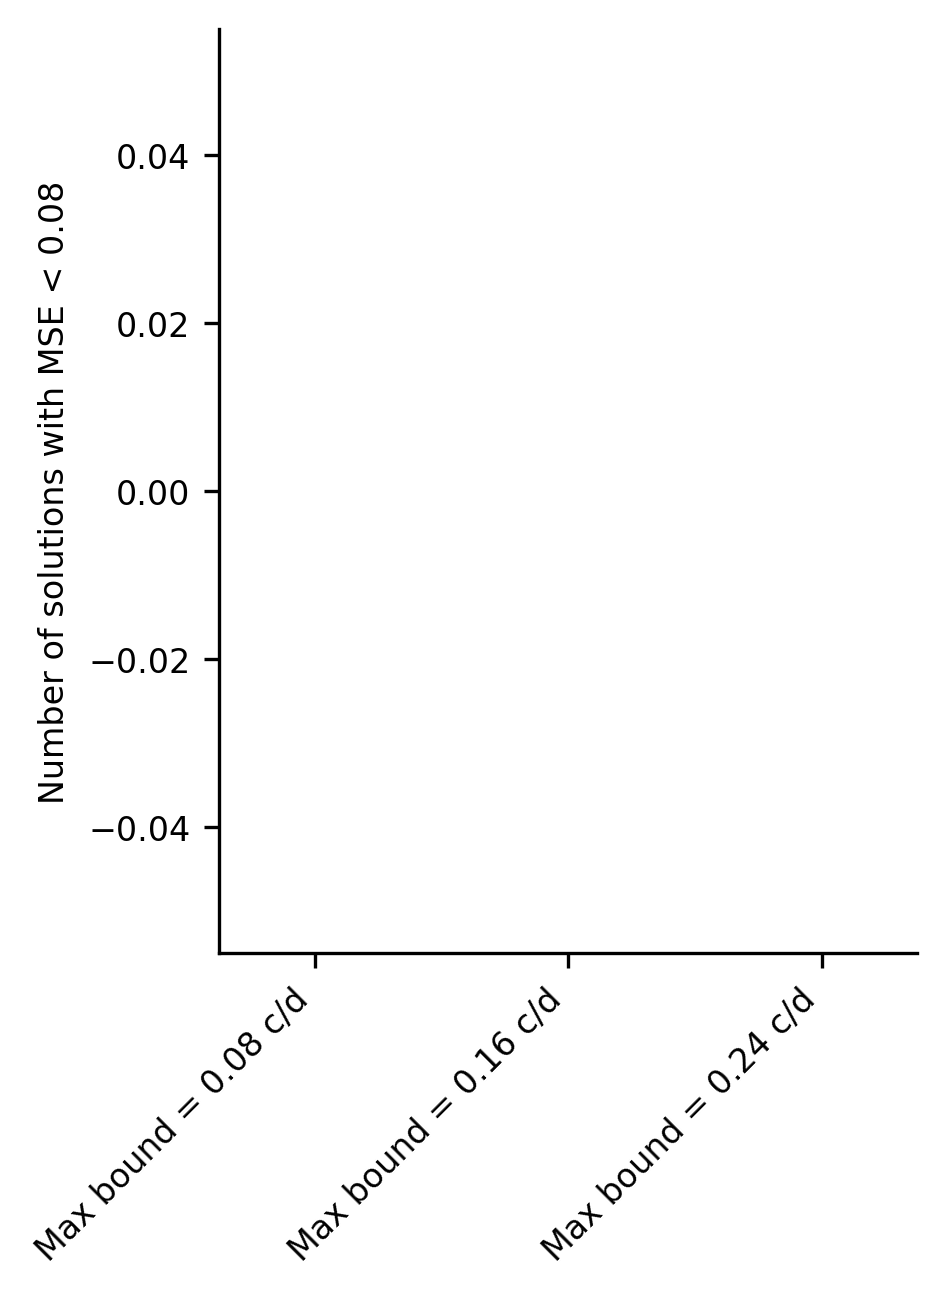

In [ ]:
fig, ax = plt.subplots(figsize = (3,4))
labels = [
    f"Max bound = {x} c/d"
    for x in upper_bounds
]
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize = fontsize)
ax.bar(labels, under_thresh, color = 'black', width = 0.5)
ax.set_xticks(np.arange(3))
ax.set_xticklabels(labels, rotation = 45, ha = 'right', fontsize = 8)
ax.set_ylabel("Number of solutions with MSE < 0.08", fontsize = 8)

In [ ]:
optimizations